# INTRODUCCIÓN.

El presente proyecto tiene como objetivo desarrollar un modelo predictivo de deserción de clientes (churn) para la empresa de telecomunicaciones Interconnect. En un mercado altamente competitivo, la retención de clientes se ha convertido en una prioridad estratégica, ya que el costo de adquirir nuevos clientes es significativamente mayor que el de mantener a los existentes.

Interconnect busca implementar una solución de machine learning que permita identificar proactivamente a los clientes con mayor probabilidad de cancelar sus servicios, facilitando así la implementación de estrategias de retención dirigidas y optimizando los recursos destinados a estas campañas.

El análisis se basa en datos históricos de 7,043 clientes que incluyen información contractual, demográfica, y de servicios contratados (internet, telefonía y servicios adicionales), abarcando el período desde octubre de 2013 hasta febrero de 2020.


# DESCRIPCIÓN DEL PROCESO

## 1. Exploración y Preparación de Datos
Se realizó un análisis exhaustivo de cuatro datasets independientes:

Contract: Información contractual (7,043 registros) incluyendo fechas, tipo de contrato, facturación y métodos de pago
Personal: Datos demográficos (7,043 registros) con género, edad senior, pareja y dependientes
Internet: Servicios de internet (5,517 registros) con tipo de conexión y servicios adicionales
Phone: Servicios telefónicos (6,361 registros) con información de líneas múltiples
Principales hallazgos del EDA:

Tasa de churn general: 26.5% (1,869 de 7,043 clientes)
Distribución equilibrada por género (50.5% hombres, 49.5% mujeres)
16.2% de clientes senior citizens
Preferencia por fibra óptica (56.1%) sobre DSL (43.9%)
Concentración de cancelaciones entre octubre 2019 y enero 2020

## 2. Integración y Limpieza de Datos
Se unificaron los datasets mediante customer_id utilizando left joins para preservar la integridad del universo de clientes. Se implementaron las siguientes transformaciones:

Conversión de tipos de datos (fechas, numéricos)
Estandarización a snake_case
Creación de la variable objetivo churned basada en end_date
Tratamiento de valores faltantes con 'no_contract' para servicios no contratados
Eliminación de 11 registros con total_charges faltantes (clientes nuevos sin historial)

## 3. Ingeniería de Características
Se desarrollaron variables derivadas para enriquecer el modelo:

Antigüedad: months_of_age calculada desde la fecha de inicio
Variables estacionales: mes y trimestre de registro
Segmentación de servicios: clasificación por tipo de servicio contratado
Segmentación por antigüedad: nuevos (≤6 meses), establecidos (6-24 meses), leales (>24 meses)

## 4. Modelado y Evaluación
Se entrenaron y compararon cuatro algoritmos de clasificación:

División de datos: 75% entrenamiento, 25% validación con random_state=12345

Modelos evaluados:

- Regresión Logística: Con escalado StandardScaler y class_weight='balanced'
  - Precision: 51.9%
  - Recall: 76.6%
  - F1-Score: 61.9%
  - AUC-ROC: 83.8%

- Árbol de Decisión: Optimizado por recall con max_depth=3
  - Precision: 45.6%
  - Recall: 90.5%
  - F1-Score: 60.7%
  - AUC-ROC: 80.6%
- Random Forest: Con n_estimators=11 y class_weight='balanced'
  - Precision: 76.0%
  - Recall: 58.5%
  - F1-Score: 66.1%
  - AUC-ROC: 86.1%

- LightGBM: Con n_estimators=20 y class_weight='balanced'
  - Precision: 61.4%
  - Recall: 83.9%
  - F1-Score: 70.9%
  - AUC-ROC: 91.1%

## 5. Selección del Modelo Final
LightGBM fue seleccionado como el modelo óptimo por presentar:

- El mejor balance general entre todas las métricas
- AUC-ROC más alto (91.1%) indicando excelente capacidad discriminativa
- F1-Score superior (70.9%) mostrando equilibrio entre precision y recall
- Recall alto (83.9%) detectando 8 de cada 10 clientes que abandonan
## 6. Análisis Segmentado
Se realizó una segmentación estratégica que reveló patrones críticos:

Por tipo de servicio:
- Clientes con ambos servicios: 32.0% churn
- Solo internet: 31.8% churn
- Solo teléfono: 2.9% churn
- Sin servicios: 8.7% churn

Por antigüedad:
- Clientes nuevos (≤6 meses): 47.1% churn
- Establecidos (6-24 meses): 36.9% churn
- Leales (>24 meses): 15.2% churn

# Analisis Exploratorio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score


In [ ]:
# Leemos cada archivo
df_contract = pd.read_csv('data/contract.csv')

df_personal = pd.read_csv('data/personal.csv')

df_internet = pd.read_csv('data/internet.csv')

df_phone = pd.read_csv('data/phone.csv')

## Contract

In [3]:
# Mostramos las primeras 5 filas
df_contract.head(5)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
# Mostramos la información general.
df_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [5]:
# Cambiamos los nombres de columnas a snake_case
df_contract.columns = ['customer_id',
                       'begin_date',
                       'end_date',
                       'type',
                       'paperless_billing',
                       'payment_method',
                       'monthly_charges',
                       'total_charges'
                      ]

In [6]:
# Mostramos el cambio
df_contract.columns

Index(['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')

In [7]:
# Comprobamos valores unicos en customer_id
print('Valores Unicos', df_contract['customer_id'].value_counts())
print('Valores duplicados', df_contract['customer_id'].duplicated().sum())

Valores Unicos customer_id
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
Valores duplicados 0


In [8]:
# Mostramos valores unicos en begin_date
df_contract['begin_date'].value_counts()

,count
begin_date,
2014-02-01,366
2019-09-01,237
2019-10-01,237
2019-11-01,237
2020-01-01,233
...,...
2020-02-01,11
2014-01-01,7
2013-10-01,3


In [9]:
# Mostramos la primera y la última fecha de registro
print('Primera fecha de registro:', df_contract['begin_date'].min())
print('Ultima fecha de registro:', df_contract['begin_date'].max())

Primera fecha de registro: 2013-10-01
Ultima fecha de registro: 2020-02-01


In [10]:
# Cambiamos a datetime
df_contract['begin_date'] = pd.to_datetime(df_contract['begin_date'])

In [11]:
#Mostramos valores unicos
print(df_contract['end_date'].value_counts())

end_date
No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: count, dtype: int64


In [12]:
# Reemplazamos "No" por NaN
df_contract['end_date'] = df_contract['end_date'].replace('No', pd.NA)
df_contract['end_date'] = pd.to_datetime(df_contract['end_date'])

In [13]:
# Cambiamos los tipos de datos
df_contract['monthly_charges'] = df_contract['monthly_charges'].astype(float)

In [14]:
# Reemplazar espacios en blanco con NaN
df_contract['total_charges'] = df_contract['total_charges'].replace(' ', pd.NA)
df_contract['total_charges'] = pd.to_numeric(df_contract['total_charges'], errors='coerce')

In [15]:
# Mostramos valores unicos en type.
print(df_contract['type'].value_counts())

type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [16]:
# Ajustamos type a snake_case
df_contract['type'] = df_contract['type'].replace('Month-to-month', 'month_to_month')
df_contract['type'] = df_contract['type'].replace('Two year', 'two_year')
df_contract['type'] = df_contract['type'].replace('One year', 'one_year')

In [17]:
# Comprobamos valores unicos en type.
print(df_contract['type'].value_counts())

type
month_to_month    3875
two_year          1695
one_year          1473
Name: count, dtype: int64


In [18]:
print(df_contract['payment_method'].value_counts())

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [19]:
# Ajustamos payment_method a snake_case
df_contract['payment_method'] = df_contract['payment_method'].replace('Electronic check', 'electronic_check')
df_contract['payment_method'] = df_contract['payment_method'].replace('Mailed check', 'mailed_check')
df_contract['payment_method'] = df_contract['payment_method'].replace('Bank transfer (automatic)', 'bank_transfer_automatic')
df_contract['payment_method'] = df_contract['payment_method'].replace('Credit card (automatic)', 'credit_card_automatic')

In [20]:
# Comprobamos los cambios
print(df_contract['payment_method'].value_counts())

payment_method
electronic_check           2365
mailed_check               1612
bank_transfer_automatic    1544
credit_card_automatic      1522
Name: count, dtype: int64


In [21]:
# Comprobamos valores unicos en paperless_billing
print(df_contract['paperless_billing'].value_counts())

paperless_billing
Yes    4171
No     2872
Name: count, dtype: int64


In [22]:
# Ajustamos paperless_billing a snake_case
df_contract['paperless_billing'] = df_contract['paperless_billing'].replace('Yes', 'yes')
df_contract['paperless_billing'] = df_contract['paperless_billing'].replace('No', 'no')

In [23]:
# Comprobamos valores unicos en paperless_billing
print(df_contract['paperless_billing'].value_counts())

paperless_billing
yes    4171
no     2872
Name: count, dtype: int64


In [24]:
# Contamos NaN
df_contract.isna().sum()

,0
customer_id,0
begin_date,0
end_date,5174
type,0
paperless_billing,0
payment_method,0
monthly_charges,0
total_charges,11


In [25]:
# Observamos las filas con NaN en total_charges
df_contract[df_contract['total_charges'].isna()]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,two_year,yes,bank_transfer_automatic,52.55,NaN
753,3115-CZMZD,2020-02-01,NaT,two_year,no,mailed_check,20.25,NaN
936,5709-LVOEQ,2020-02-01,NaT,two_year,no,mailed_check,80.85,NaN
1082,4367-NUYAO,2020-02-01,NaT,two_year,no,mailed_check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,NaT,two_year,no,credit_card_automatic,56.05,NaN
3331,7644-OMVMY,2020-02-01,NaT,two_year,no,mailed_check,19.85,NaN
3826,3213-VVOLG,2020-02-01,NaT,two_year,no,mailed_check,25.35,NaN
4380,2520-SGTTA,2020-02-01,NaT,two_year,no,mailed_check,20.00,NaN
5218,2923-ARZLG,2020-02-01,NaT,one_year,yes,mailed_check,19.70,NaN
6670,4075-WKNIU,2020-02-01,NaT,two_year,no,mailed_check,73.35,NaN


In [26]:
# Creamos una columna llamada churned
df_contract['churned'] = df_contract['end_date'].notna().astype(int)

In [27]:
# Contamos clientes desertados
df_contract['churned'].value_counts()

,count
churned,
0,5174
1,1869


In [28]:
df_contract.head(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churned
0,7590-VHVEG,2020-01-01,NaT,month_to_month,yes,electronic_check,29.85,29.85,0
1,5575-GNVDE,2017-04-01,NaT,one_year,no,mailed_check,56.95,1889.50,0
2,3668-QPYBK,2019-10-01,2019-12-01,month_to_month,yes,mailed_check,53.85,108.15,1
3,7795-CFOCW,2016-05-01,NaT,one_year,no,bank_transfer_automatic,42.30,1840.75,0
4,9237-HQITU,2019-09-01,2019-11-01,month_to_month,yes,electronic_check,70.70,151.65,1


In [29]:
df_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1869 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   churned            7043 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 495.3+ KB


In [30]:
# Mostramos la descripción estadística
df_contract.describe()

,begin_date,end_date,monthly_charges,total_charges,churned
count,7043,1869,7043.000000,7032.000000,7043.000000
mean,2017-04-30 13:01:50.918642688,2019-11-15 21:31:18.009630976,64.761692,2283.300441,0.265370
min,2013-10-01 00:00:00,2019-10-01 00:00:00,18.250000,18.800000,0.000000
25%,2015-06-01 00:00:00,2019-11-01 00:00:00,35.500000,401.450000,0.000000
50%,2017-09-01 00:00:00,2019-11-01 00:00:00,70.350000,1397.475000,0.000000
75%,2019-04-01 00:00:00,2019-12-01 00:00:00,89.850000,3794.737500,1.000000
max,2020-02-01 00:00:00,2020-01-01 00:00:00,118.750000,8684.800000,1.000000
std,NaN,NaN,30.090047,2266.771362,0.441561


In [31]:
# Contamos filas totalmente duplicadas
df_contract.duplicated().sum()

np.int64(0)

In [34]:
numeric_df_contract = df_contract.select_dtypes(include=['number'])
# Mostramos correlaciones
numeric_df_contract.corr()

,monthly_charges,total_charges,churned
monthly_charges,1.000000,0.651065,0.193356
total_charges,0.651065,1.000000,-0.199484
churned,0.193356,-0.199484,1.000000


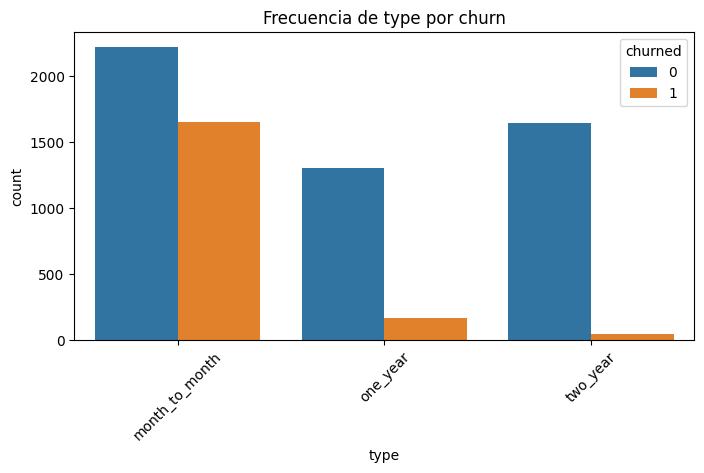

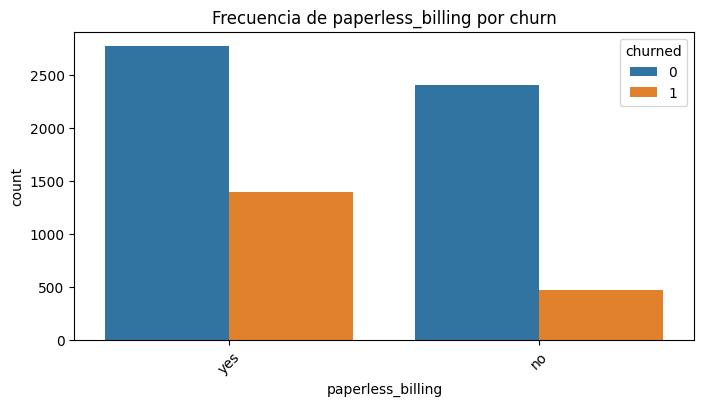

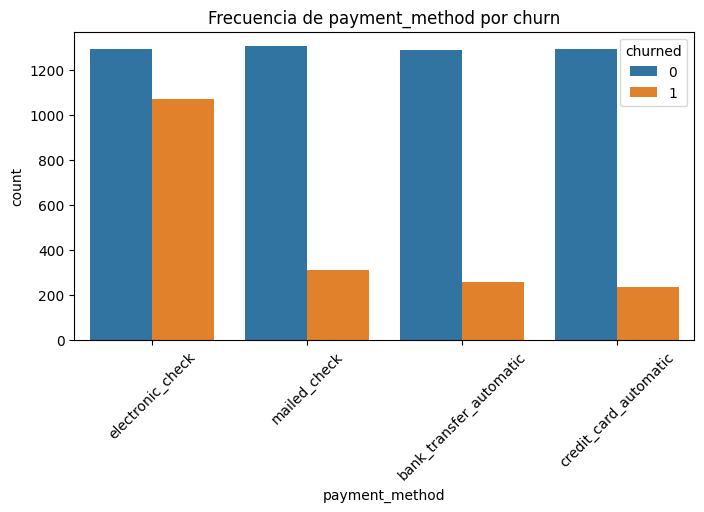

In [35]:
cat_cols = ['type', 'paperless_billing', 'payment_method']
for col in cat_cols:
    plt.figure(figsize=(8,4))  # Agregar 4 espacios de indentación
    sns.countplot(data=df_contract, x=col, hue='churned')
    plt.title(f'Frecuencia de {col} por churn')
    plt.xticks(rotation=45)
    plt.show()

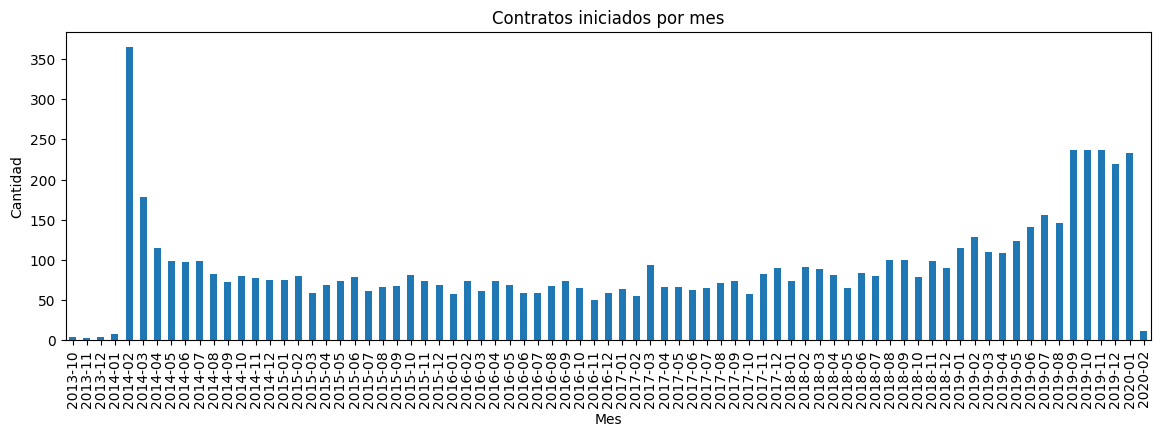

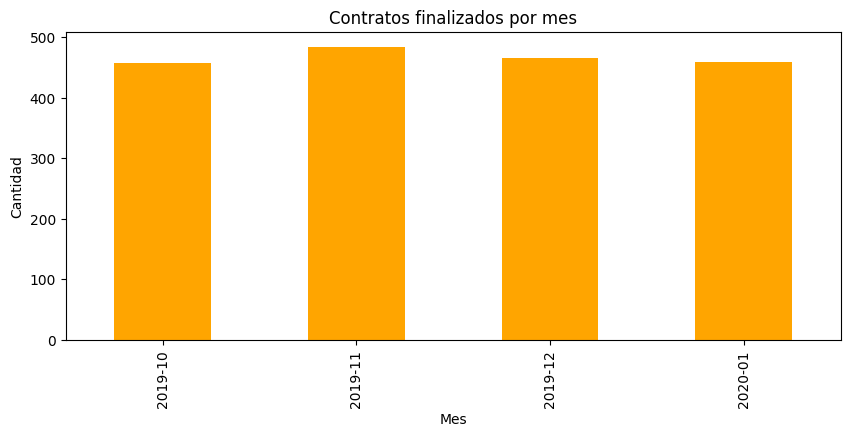

In [37]:
# Contratos iniciados por mes
plt.figure(figsize=(14,4))
df_contract['begin_date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar')
plt.title('Contratos iniciados por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.show()

# Contratos finalizados por mes
plt.figure(figsize=(10,4))
df_contract['end_date'].dropna().dt.to_period('M').value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Contratos finalizados por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.show()

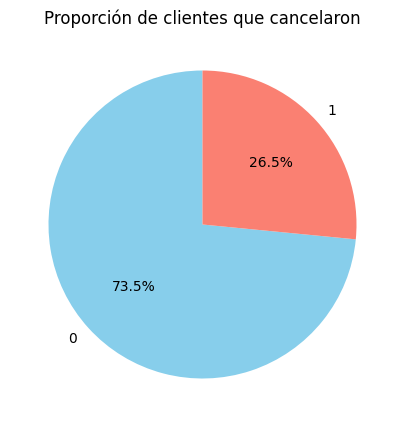

In [38]:
plt.figure(figsize=(5,5))
df_contract['churned'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue','salmon'])
plt.title('Proporción de clientes que cancelaron')
plt.ylabel('')
plt.show()

### Observaciones:

- Todos los valores de customer_id son valores únicos.
- Convertimos a los tipos de datos correctos por columna
- Las fechas de deserción de clientes se encuentra entre Octubre de 2019 y Enero de 2020.
- Primera fecha de registro: 2013-10-01 y la Ultima fecha de registro: 2020-02-01.
- En total_charges hay 11 valores ausentes, probablemente de clientes nuevos sin suficiente historial de facturación.
- monthly_charges varía entre 18.25 y 118.75, lo que sugiere distintos planes o servicios (básico a premium).
- total_charges tiene un rango amplio (18.80 a 8684.80), reflejando clientes con distinta antigüedad.
- En monthly_charges, la mediana (70.35) está cerca de la media (64.76), lo que indica una distribución relativamente simétrica, aunque algo sesgada a la derecha (planes más caros menos frecuentes).
- En total_charges, la diferencia entre media (2283) y mediana (1397) muestra una cola derecha pronunciada, es decir, unos pocos clientes con cargos totales muy altos.
- De 7043 clientes, 5174 permanecen y  1869 han cancelado. Dejando asi un 73,46% de clientes vigentes y un 26,54% de cancelados.

## Personal

In [39]:
# Mostramos las primeras 5 filas
df_personal.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [40]:
# Cambiamso nombres a snake_case
df_personal.columns = [
    'customer_id',
    'gender',
    'senior_citizen',
    'partner',
    'dependents'
]

In [41]:
# Comprobamos cambios
df_personal.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents'], dtype='object')

In [42]:
# Mostramos informacion general
df_personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [43]:
# Buscamos duplicados en customer_id
df_personal[df_personal['customer_id'].duplicated()]

,customer_id,gender,senior_citizen,partner,dependents


In [44]:
# Mostramos los valores unicos en gender
df_personal['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [45]:
# Cambiamos a snake_case
df_personal['gender'] = df_personal['gender'].replace('Male', 'male')
df_personal['gender'] = df_personal['gender'].replace('Female', 'female')

In [46]:
# Comprobamos los valores unicos en gender
df_personal['gender'].value_counts()

,count
gender,
male,3555
female,3488


In [47]:
# Mostramos los valores unicos en senior_citizen
df_personal['senior_citizen'].value_counts()

,count
senior_citizen,
0,5901
1,1142


In [48]:
# Mostramos los valores unicos en partner
df_personal['partner'].value_counts()

,count
partner,
No,3641
Yes,3402


In [49]:
# Mostramos los valores unicos en dependents
df_personal['dependents'].value_counts()

,count
dependents,
No,4933
Yes,2110


In [50]:
# Cambiamos a snake_case
df_personal['dependents'] = df_personal['dependents'].replace('No', 'no')
df_personal['dependents'] = df_personal['dependents'].replace('Yes', 'yes')

In [51]:
# Comprobamos los valores unicos en dependents
df_personal['dependents'].value_counts()

,count
dependents,
no,4933
yes,2110


In [52]:
# Contamos NaN
df_personal.isna().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0


In [53]:
# Contamos filas totalmente duplicdas
df_personal.duplicated().sum()

np.int64(0)

In [54]:
# Mostramos estadisticas
df_personal.describe()

,senior_citizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [56]:
# Seleccionamos solo las columnas numéricas para calcular la correlación
numeric_df_personal = df_personal.select_dtypes(include=['number'])
# Mostramos correlaciones
numeric_df_personal.corr()

,senior_citizen
senior_citizen,1.0


/tmp/ipython-input-1648702000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_personal, x=col, palette='Set2')


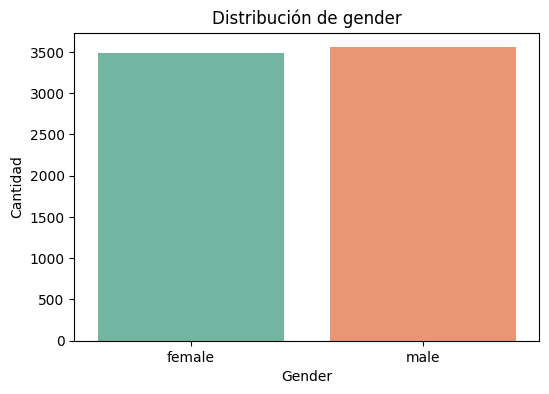

/tmp/ipython-input-1648702000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_personal, x=col, palette='Set2')


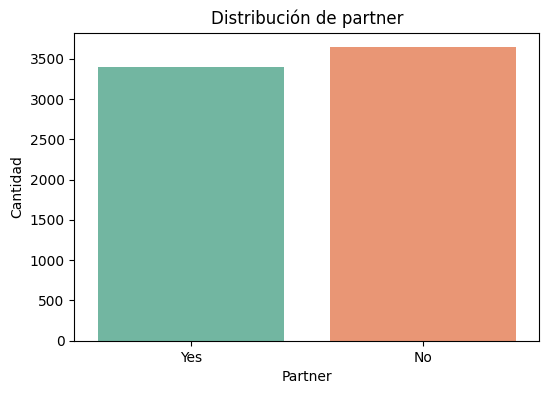

/tmp/ipython-input-1648702000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_personal, x=col, palette='Set2')


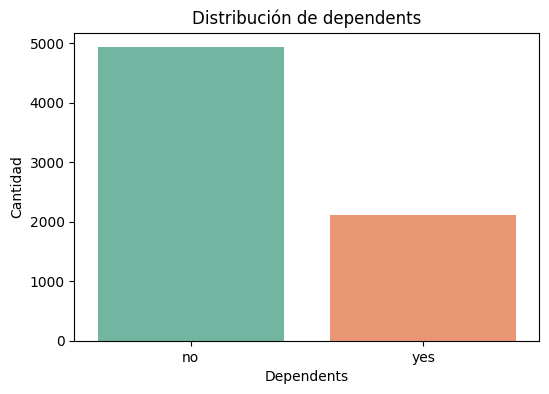

/tmp/ipython-input-1648702000.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_personal, x=bin_col, palette='coolwarm')


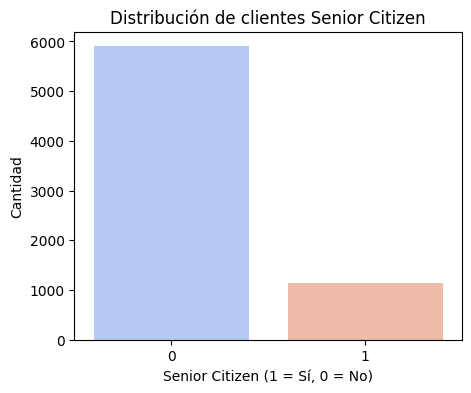

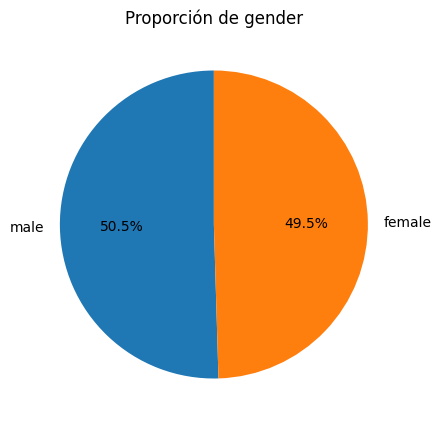

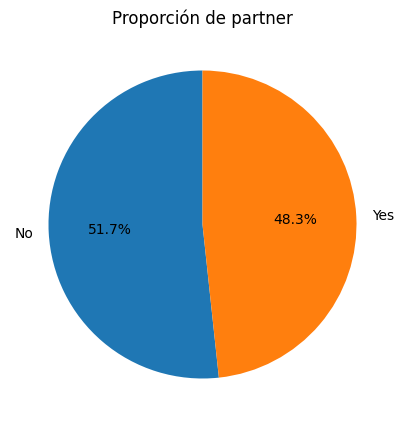

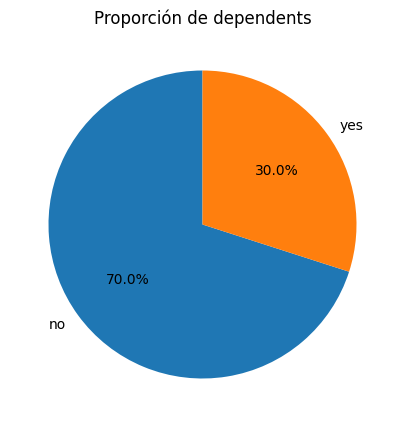

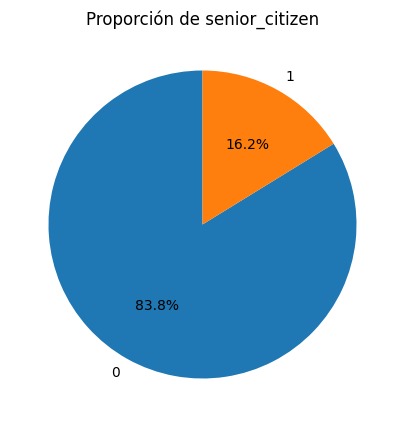

In [57]:
# Lista de columnas categóricas y binarias
cat_cols = ['gender', 'partner', 'dependents']
bin_col = 'senior_citizen'

# Distribución de variables categóricas
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_personal, x=col, palette='Set2')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Cantidad')
    plt.show()

# Distribución de clientes senior
plt.figure(figsize=(5,4))
sns.countplot(data=df_personal, x=bin_col, palette='coolwarm')
plt.title('Distribución de clientes Senior Citizen')
plt.xlabel('Senior Citizen (1 = Sí, 0 = No)')
plt.ylabel('Cantidad')
plt.show()

# Proporción de cada categoría
for col in cat_cols + [bin_col]:
    plt.figure(figsize=(5,5))
    df_personal[col].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title(f'Proporción de {col}')
    plt.ylabel('')
    plt.show()


### Observaciones

- Tenemos 7043 filas al igual que df_contract.
- Los clientes están distribuidos en 50.5% como hombres y 49.5% como mujeres.
- Los clientes están distribuidos en 51.7% con pareja  y 48.3% sin pareja.
- Los clientes están distribuidos en 30% que tienen personas que dependen económicamente de ellos, mientras que el 70% no.
- Los clientes están distribuidos en 16.2% como jubilas y el 83.8% sin jubilación.
-

## Internet.

In [58]:
# Mostramos las primeras 5 filas
df_internet.head(5)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [59]:
# Ajustamos los nombres de las columnas a snake_case
df_internet.columns = [
    'customer_id',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

In [60]:
# Comprobamos los cambios
df_internet.columns

Index(['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies'],
      dtype='object')

In [61]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [62]:
# Comprobamos valores duplicados en customer_id
df_internet['customer_id'].duplicated().sum()

np.int64(0)

In [63]:
# Contamos valores unicos en internet_service
df_internet['internet_service'].value_counts()

,count
internet_service,
Fiber optic,3096
DSL,2421


In [64]:
# Contamos valores unicos en online_security
df_internet['online_security'].value_counts()

,count
online_security,
No,3498
Yes,2019


In [65]:
# Contamos valores unicos en online_backup
df_internet['online_backup'].value_counts()

,count
online_backup,
No,3088
Yes,2429


In [66]:
# Contamos valores unicos en device_protection
df_internet['device_protection'].value_counts()

,count
device_protection,
No,3095
Yes,2422


In [67]:
# Contamos valores unicos en tech_support
df_internet['tech_support'].value_counts()

,count
tech_support,
No,3473
Yes,2044


In [68]:
# Contamos valores unicos en streaming_tv
df_internet['streaming_tv'].value_counts()

,count
streaming_tv,
No,2810
Yes,2707


In [69]:
# Contamos valores unicos en streaming_movies
df_internet['streaming_movies'].value_counts()

,count
streaming_movies,
No,2785
Yes,2732


/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


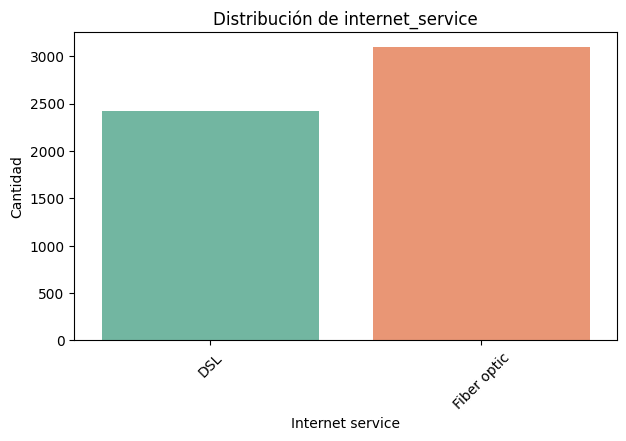

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


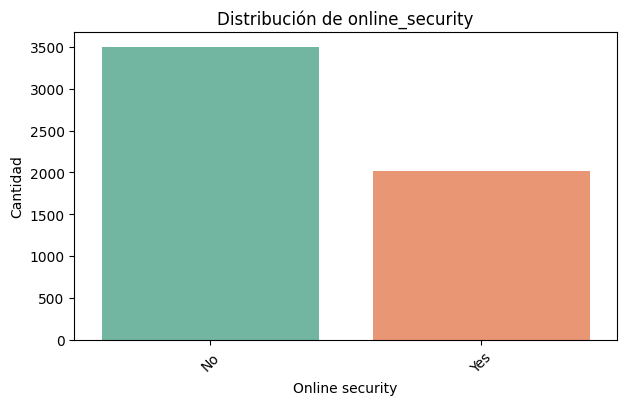

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


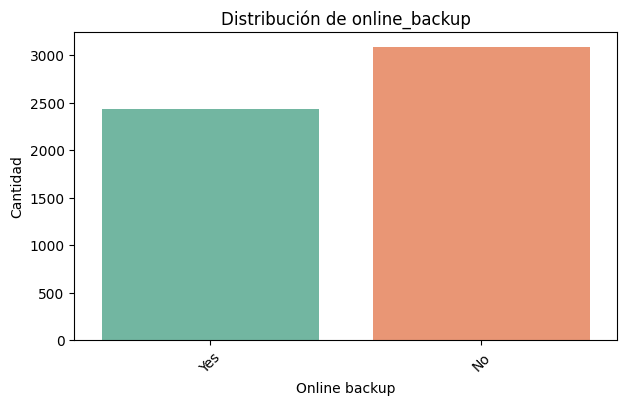

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


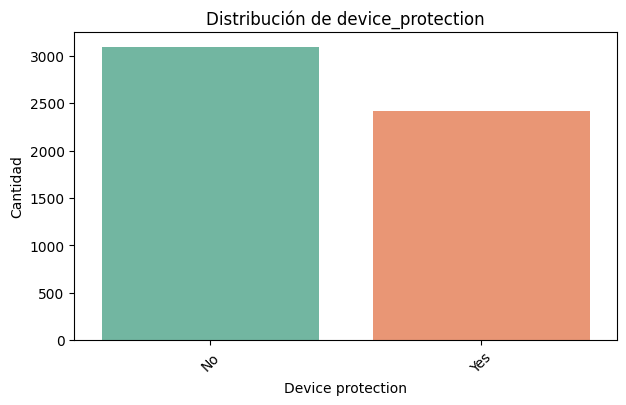

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


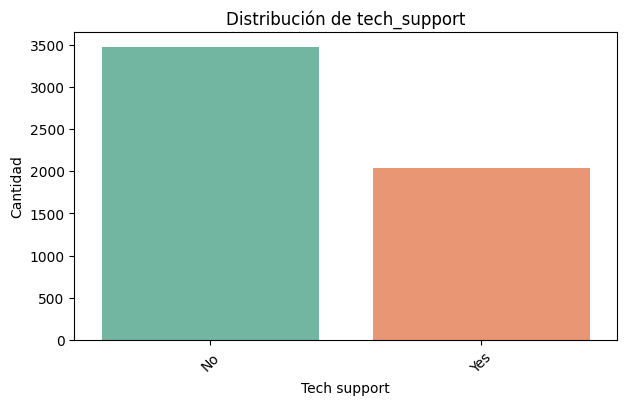

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


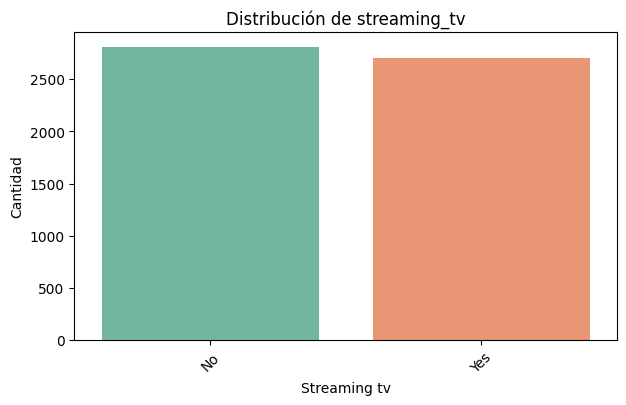

/tmp/ipython-input-2645661353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_internet, x=col, palette='Set2')


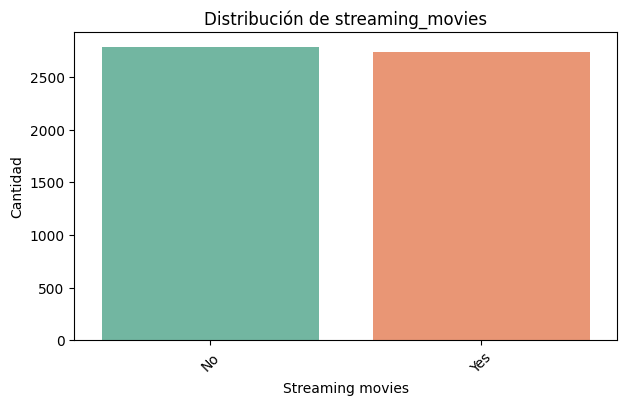

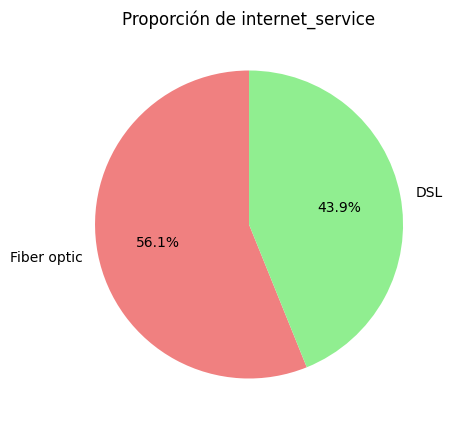

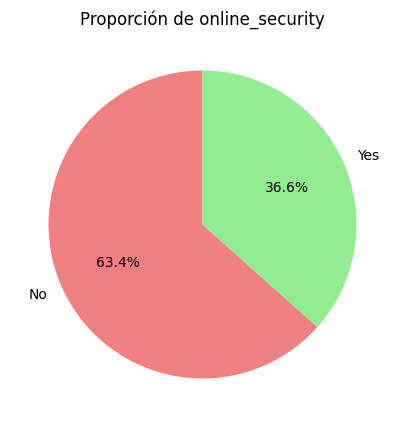

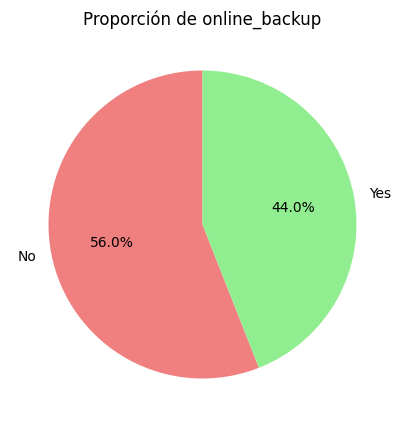

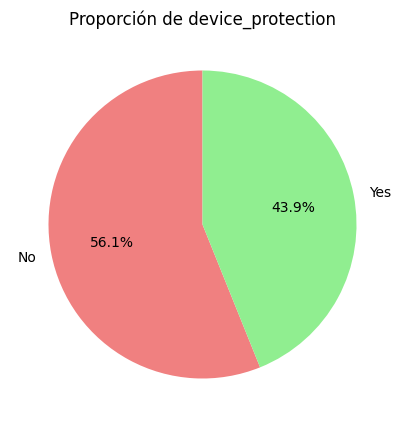

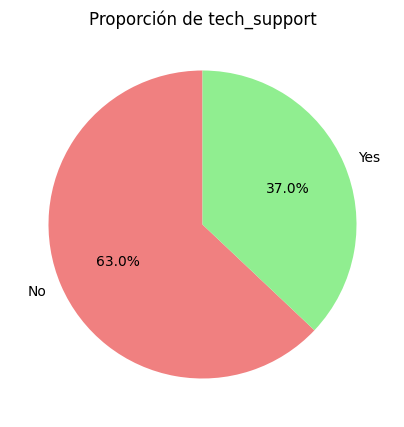

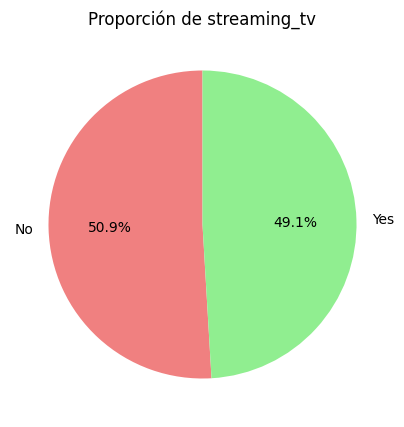

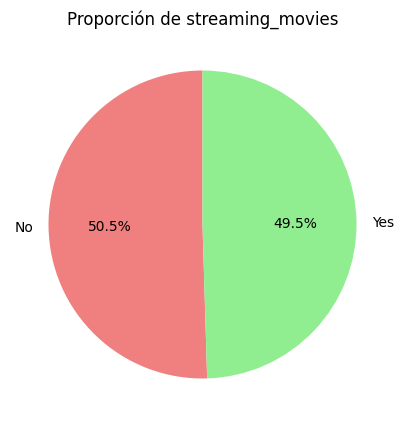

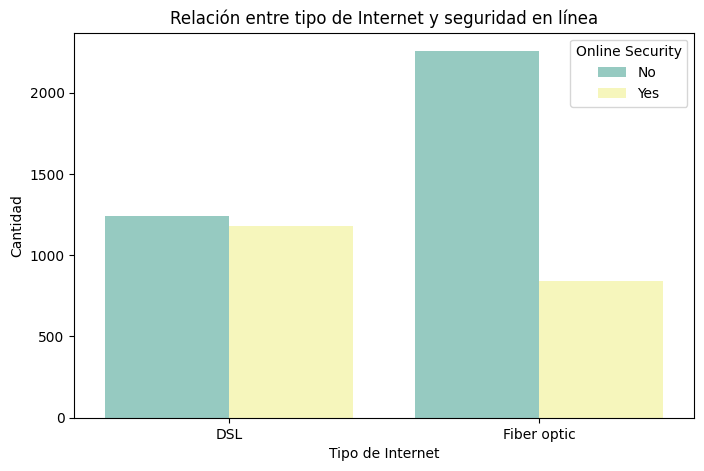

In [70]:
# Lista de columnas categóricas
cat_cols = ['internet_service', 'online_security', 'online_backup',
            'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

# Distribución general de cada variable
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df_internet, x=col, palette='Set2')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col.replace('_', ' ').capitalize())
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    plt.show()

# Proporción de servicios "Sí / No"
for col in cat_cols[0:]:  # excluimos internet_service porque tiene más de dos categorías
    plt.figure(figsize=(5,5))
    df_internet[col].value_counts(normalize=True).plot(
        kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral','lightgreen','lightgray']
    )
    plt.title(f'Proporción de {col}')
    plt.ylabel('')
    plt.show()

# Comparar tipo de servicio de Internet con uso de otros servicios
plt.figure(figsize=(8,5))
sns.countplot(data=df_internet, x='internet_service', hue='online_security', palette='Set3')
plt.title('Relación entre tipo de Internet y seguridad en línea')
plt.xlabel('Tipo de Internet')
plt.ylabel('Cantidad')
plt.legend(title='Online Security')
plt.show()

In [71]:
# Descripción Estadística
df_internet.describe()

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,3186-AJIEK,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


In [72]:
# Contamos filas duplicadas
df_internet.duplicated().sum()

np.int64(0)

In [73]:
# Contamos valores ausentes
df_internet.isna().sum()

,0
customer_id,0
internet_service,0
online_security,0
online_backup,0
device_protection,0
tech_support,0
streaming_tv,0
streaming_movies,0


### Observaciones:

- La mayoría de los clientes de Interconnect utiliza fibra óptica (56,1%), mientras que el 43,9% se conecta a través de DSL, lo que sugiere una fuerte preferencia por conexiones de mayor velocidad y estabilidad.

- En cuanto a los servicios complementarios, se observa una tendencia general a no contratarlos. Solo 36,6% de los usuarios cuenta con seguridad en línea, 44% utiliza copias de seguridad en línea, y 43,9% tiene protección de dispositivo. Del mismo modo, apenas 37% de los clientes solicita soporte técnico, lo que podría indicar que muchos usuarios perciben el servicio de Internet como suficientemente estable o que no consideran valioso el costo adicional.

- Por otro lado, los servicios de entretenimiento tienen una distribución equilibrada: Streaming de TV (49,1%) y Streaming de películas (49,5%) son utilizados casi por la mitad de los clientes, lo que refleja un interés sostenido en el consumo digital y multimedia.

- En conjunto, los datos muestran que la base de usuarios prefiere invertir en conectividad rápida y entretenimiento, mientras que los servicios de soporte y seguridad presentan una menor adopción, representando una posible oportunidad comercial para la empresa si se diseñan paquetes integrales o descuentos que incentiven su uso.

## Phone

In [74]:
# Mostramos las primeras 5 filas
df_phone.head(5)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [76]:
# Ajustamos el nombre de las columnas a snake_case
df_phone.columns = [
    'customer_id',
    'multiple_lines'
]

In [77]:
#Mostramos informacion general
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [78]:
# Comprobamos valores duplicados en customer_id
df_phone['customer_id'].duplicated().sum()

np.int64(0)

In [79]:
# Comprobamos valores ausentes
df_phone.duplicated().sum()

np.int64(0)

In [80]:
# Comprobamos valores unicos en multiple_lines
df_phone['multiple_lines'].value_counts()

,count
multiple_lines,
No,3390
Yes,2971


In [81]:
# Descripción Estadística
df_phone.describe()

,customer_id,multiple_lines
count,6361,6361
unique,6361,2
top,3186-AJIEK,No
freq,1,3390


## Observaciones.

- El servicio telefónico cuenta con un total de 6.361 clientes, lo que indica que no todos los usuarios de la base general (7.043) tienen contratado este servicio.

- Entre quienes sí lo utilizan: 53,3% (3.390 clientes) tienen una línea única, mientras que 46,7% (2.971 clientes) cuentan con múltiples líneas. Esto muestra una distribución relativamente equilibrada, aunque con una ligera preferencia por mantener una sola línea.

# Plan de Acción Propuesto.

1. **Integración y preparación de los datos**

   * Unificar los diferentes DataFrames (`contract`, `personal`, `internet`, `phone`) en un único conjunto de datos a partir de la clave `customer_id`.
   * Realizar una codificación adecuada de las variables categóricas y escalar las variables numéricas según corresponda, garantizando la compatibilidad con los algoritmos de clasificación.
   * Manejar valores ausentes y revisar la coherencia de los tipos de datos para asegurar un dataset limpio y estructurado.

2. **Entrenamiento del modelo de clasificación**

   * Dividir los datos en conjuntos de entrenamiento y prueba (por ejemplo, 75% / 25%).
   * Probar distintos modelos de clasificación (Regresión Logística, Árboles de Decisión, Random Forest, LightGBM, etc.) para identificar cuál ofrece el mejor equilibrio entre rendimiento y explicabilidad.

3. **Evaluación y optimización del modelo**

   * Evaluar el desempeño del modelo mediante las métricas acordadas con el cliente (por ejemplo, **ROC-AUC**, **F1-score**, **Recall**).
   * Ajustar hiperparámetros y comparar resultados para asegurar un modelo estable, reproducible y con capacidad predictiva adecuada.

4. **Validación final**

   * Probar el modelo con el 25% de los datos reservados para testeo y analizar los resultados de generalización.
   * Realizar una comparación entre las predicciones y las cancelaciones reales para identificar patrones relevantes de deserción.

5. **Comunicación de hallazgos y recomendaciones**

   * Socializar los resultados del modelo, destacando los principales factores asociados a la cancelación de clientes.
   * Proponer acciones o estrategias de retención basadas en las variables más influyentes detectadas por el modelo.

# Preguntas aclaratorias.

Con el fin de asegurar que el modelo predictivo responda adecuadamente a las necesidades del negocio, se proponen las siguientes preguntas de clarificación:

1. **Destinatarios de los resultados:**
   ¿Quiénes serán los principales receptores del análisis y de los resultados del modelo (por ejemplo, directivos, equipo de marketing, área técnica)?

   > *Esto permitirá adaptar el nivel de tecnicismo, lenguaje y visualizaciones del informe final.*

2. **Nivel de detalle esperado:**
   ¿Qué nivel de profundidad se requiere en la presentación de resultados?

   > *Por ejemplo, si se esperan únicamente conclusiones ejecutivas o una interpretación completa del comportamiento del modelo.*

3. **Segmentación o información adicional requerida:**
   ¿Se requiere segmentar los resultados por tipo de cliente o servicio?

   > *Por ejemplo, distinguir entre usuarios de telefonía, internet, ambos, o entre clientes nuevos y antiguos. Esto definiría la granularidad de las predicciones (mensuales, trimestrales, etc.).*

4. **Métricas de evaluación preferidas:**
   ¿Existen métricas prioritarias para evaluar el modelo (por ejemplo, ROC-AUC, F1, Recall, o precisión)?

   > *Algunas métricas se centran en minimizar falsos positivos, mientras que otras priorizan detectar la mayor cantidad de clientes propensos a abandonar.*

5. **Prioridad del modelo:**
   ¿Qué se debe priorizar: la interpretabilidad del modelo o el rendimiento predictivo?

   > *Esto permitirá decidir entre modelos explicables (como regresión logística) o más complejos y potentes (como LightGBM o XGBoost).*

6. **Costos asociados a los errores de predicción:**
   ¿Existen costos o penalizaciones asociadas a los falsos negativos, es decir, a los clientes que realmente abandonan pero el modelo no detecta?

   > *Comprender este aspecto ayuda a ajustar los umbrales de decisión y priorizar la métrica más relevante para el negocio.*

# Preparativos para los modelos predictivos.

## Dataframe unificado.

In [82]:
# Creamos un df con la informacion del contrato y la informacion personal de cada cliente.
df = df_contract.merge(df_personal,
                       left_on = 'customer_id',
                       right_on = 'customer_id',
                       how = 'left'
                      )

In [83]:
# Mostramos las primeras 5 filas de df
df.head(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churned,gender,senior_citizen,partner,dependents
0,7590-VHVEG,2020-01-01,NaT,month_to_month,yes,electronic_check,29.85,29.85,0,female,0,Yes,no
1,5575-GNVDE,2017-04-01,NaT,one_year,no,mailed_check,56.95,1889.50,0,male,0,No,no
2,3668-QPYBK,2019-10-01,2019-12-01,month_to_month,yes,mailed_check,53.85,108.15,1,male,0,No,no
3,7795-CFOCW,2016-05-01,NaT,one_year,no,bank_transfer_automatic,42.30,1840.75,0,male,0,No,no
4,9237-HQITU,2019-09-01,2019-11-01,month_to_month,yes,electronic_check,70.70,151.65,1,female,0,No,no


In [84]:
# Agregamos la informacion del servicio de internet
df = df.merge(df_internet,
                       left_on = 'customer_id',
                       right_on = 'customer_id',
                       how = 'left'
                      )

In [85]:
# Mostramos las primeras 5 filas de df
df.head(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churned,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,2020-01-01,NaT,month_to_month,yes,electronic_check,29.85,29.85,0,female,0,Yes,no,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,2017-04-01,NaT,one_year,no,mailed_check,56.95,1889.50,0,male,0,No,no,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,month_to_month,yes,mailed_check,53.85,108.15,1,male,0,No,no,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,one_year,no,bank_transfer_automatic,42.30,1840.75,0,male,0,No,no,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2019-09-01,2019-11-01,month_to_month,yes,electronic_check,70.70,151.65,1,female,0,No,no,Fiber optic,No,No,No,No,No,No


In [86]:
# Agregamos la informacion del servicio de telefono.
df = df.merge(df_phone,
                       left_on = 'customer_id',
                       right_on = 'customer_id',
                       how = 'left'
                      )

In [87]:
# Mostramos las primeras 5 filas de df
df.head(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churned,gender,...,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,month_to_month,yes,electronic_check,29.85,29.85,0,female,...,Yes,no,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,one_year,no,mailed_check,56.95,1889.50,0,male,...,No,no,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,month_to_month,yes,mailed_check,53.85,108.15,1,male,...,No,no,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,one_year,no,bank_transfer_automatic,42.30,1840.75,0,male,...,No,no,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,month_to_month,yes,electronic_check,70.70,151.65,1,female,...,No,no,Fiber optic,No,No,No,No,No,No,No


In [88]:
# Fecha de referencia (puedes usar la fecha más reciente de tu dataset)
fecha_referencia = df['begin_date'].max()

# 1. Antigüedad en meses
df['months_of_age'] = (fecha_referencia - df['begin_date']).dt.days / 30.44

# 2. Variables estacionales
df['month_registration'] = df['begin_date'].dt.month
df['quarter_registration'] = df['begin_date'].dt.quarter

In [89]:
# Mostramos las primeras 5 filas de df
df.head(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churned,gender,...,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,months_of_age,month_registration,quarter_registration
0,7590-VHVEG,2020-01-01,NaT,month_to_month,yes,electronic_check,29.85,29.85,0,female,...,No,Yes,No,No,No,No,NaN,1.018397,1,1
1,5575-GNVDE,2017-04-01,NaT,one_year,no,mailed_check,56.95,1889.50,0,male,...,Yes,No,Yes,No,No,No,No,34.034166,4,2
2,3668-QPYBK,2019-10-01,2019-12-01,month_to_month,yes,mailed_check,53.85,108.15,1,male,...,Yes,Yes,No,No,No,No,No,4.040736,10,4
3,7795-CFOCW,2016-05-01,NaT,one_year,no,bank_transfer_automatic,42.30,1840.75,0,male,...,Yes,No,Yes,Yes,No,No,NaN,45.039422,5,2
4,9237-HQITU,2019-09-01,2019-11-01,month_to_month,yes,electronic_check,70.70,151.65,1,female,...,No,No,No,No,No,No,No,5.026281,9,3


In [90]:
# Eliminamos las columnas inncesarias
df = df.drop(['begin_date', 'end_date'], axis= 1)

In [91]:
# Mostramos los valores ausentes
df.isna().sum()

,0
customer_id,0
type,0
paperless_billing,0
payment_method,0
monthly_charges,0
total_charges,11
churned,0
gender,0
senior_citizen,0
partner,0


In [92]:
# Eliminar filas con valores faltantes en total_charges
df = df.dropna(subset=['total_charges'])

In [93]:
# Reemplazamos las columnas categoricas sobre los servicios de intenet y celular como 'no_contract'
df = df.fillna('no_contract')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [88], rellenar los faltantes de columnas de servicios con <code>'no_contract'</code> tras las uniones es una decisión alineada con la lógica del dato: si no aparece en el dataset del servicio, el cliente no lo tiene contratado. Esto unifica criterios, evita <code>NaN</code> ambiguos y prepara bien la codificación posterior. Buena consistencia entre el EDA y el preprocesamiento.
</div>

In [94]:
# Mostramos los valores ausentes
df.isna().sum()

,0
customer_id,0
type,0
paperless_billing,0
payment_method,0
monthly_charges,0
total_charges,0
churned,0
gender,0
senior_citizen,0
partner,0


In [95]:
# Mostramos las primeras 5 filas de df
df.head(5)

,customer_id,type,paperless_billing,payment_method,monthly_charges,total_charges,churned,gender,senior_citizen,partner,...,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,months_of_age,month_registration,quarter_registration
0,7590-VHVEG,month_to_month,yes,electronic_check,29.85,29.85,0,female,0,Yes,...,No,Yes,No,No,No,No,no_contract,1.018397,1,1
1,5575-GNVDE,one_year,no,mailed_check,56.95,1889.50,0,male,0,No,...,Yes,No,Yes,No,No,No,No,34.034166,4,2
2,3668-QPYBK,month_to_month,yes,mailed_check,53.85,108.15,1,male,0,No,...,Yes,Yes,No,No,No,No,No,4.040736,10,4
3,7795-CFOCW,one_year,no,bank_transfer_automatic,42.30,1840.75,0,male,0,No,...,Yes,No,Yes,Yes,No,No,no_contract,45.039422,5,2
4,9237-HQITU,month_to_month,yes,electronic_check,70.70,151.65,1,female,0,No,...,No,No,No,No,No,No,No,5.026281,9,3


In [96]:
# Mostramos informacion general
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           7032 non-null   object 
 1   type                  7032 non-null   object 
 2   paperless_billing     7032 non-null   object 
 3   payment_method        7032 non-null   object 
 4   monthly_charges       7032 non-null   float64
 5   total_charges         7032 non-null   float64
 6   churned               7032 non-null   int64  
 7   gender                7032 non-null   object 
 8   senior_citizen        7032 non-null   int64  
 9   partner               7032 non-null   object 
 10  dependents            7032 non-null   object 
 11  internet_service      7032 non-null   object 
 12  online_security       7032 non-null   object 
 13  online_backup         7032 non-null   object 
 14  device_protection     7032 non-null   object 
 15  tech_support          7032

In [97]:
# Mostramos estadisticas
df.describe()

,monthly_charges,total_charges,churned,senior_citizen,months_of_age,month_registration,quarter_registration
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,64.798208,2283.300441,0.265785,0.162400,33.115356,6.428185,2.471985
std,30.085974,2266.771362,0.441782,0.368844,24.181834,3.576972,1.157273
min,18.250000,18.800000,0.000000,0.000000,1.018397,1.000000,1.000000
25%,35.587500,401.450000,0.000000,0.000000,10.052562,3.000000,1.000000
50%,70.350000,1397.475000,0.000000,0.000000,29.007884,6.000000,2.000000
75%,89.862500,3794.737500,1.000000,0.000000,56.044678,10.000000,4.000000
max,118.750000,8684.800000,1.000000,1.000000,76.018397,12.000000,4.000000


In [99]:
# Seleccionamos solo las columnas numéricas para calcular la correlación
numeric_df = df.select_dtypes(include=['number'])
# Mostramos correlacion
numeric_df.corr()

,monthly_charges,total_charges,churned,senior_citizen,months_of_age,month_registration,quarter_registration
monthly_charges,1.000000,0.651065,0.192858,0.219874,0.259819,-0.019613,-0.029945
total_charges,0.651065,1.000000,-0.199484,0.102411,0.829135,-0.196624,-0.209060
churned,0.192858,-0.199484,1.000000,0.150541,-0.313547,0.180522,0.173829
senior_citizen,0.219874,0.102411,0.150541,1.000000,0.022550,0.028569,0.020656
months_of_age,0.259819,0.829135,-0.313547,0.022550,1.000000,-0.230676,-0.245454
month_registration,-0.019613,-0.196624,0.180522,0.028569,-0.230676,1.000000,0.974156
quarter_registration,-0.029945,-0.209060,0.173829,0.020656,-0.245454,0.974156,1.000000


## Codificación

In [100]:
# Mapeo manual para mayor control
mapping = {
    'yes': 1, 'no': 0,
    'Yes': 1, 'No': 0,
    'male': 1, 'female': 0,
    'no_contract': 0,
    'Fiber optic': 1,
    'DSL': 2,
    'electronic_check': 0,
    'mailed_check': 1,
    'bank_transfer_automatic': 2,
    'credit_card_automatic': 3,
    'month_to_month': 0,
    'two_year': 1,
    'one_year':2
}
columns_list = ['type', 'payment_method', 'multiple_lines','internet_service',
                'online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies',
                'paperless_billing', 'partner', 'dependents', 'gender'
                ]

for col in columns_list:
    df[col] = df[col].map(mapping)

In [101]:
for col in columns_list:
    print(f'Para {col}: \n {df[col].value_counts()} \n ------------')

Para type: 
 type
0    3875
1    1685
2    1472
Name: count, dtype: int64 
 ------------
Para payment_method: 
 payment_method
0    2365
1    1604
2    1542
3    1521
Name: count, dtype: int64 
 ------------
Para multiple_lines: 
 multiple_lines
0    4065
1    2967
Name: count, dtype: int64 
 ------------
Para internet_service: 
 internet_service
1    3096
2    2416
0    1520
Name: count, dtype: int64 
 ------------
Para online_security: 
 online_security
0    5017
1    2015
Name: count, dtype: int64 
 ------------
Para online_backup: 
 online_backup
0    4607
1    2425
Name: count, dtype: int64 
 ------------
Para device_protection: 
 device_protection
0    4614
1    2418
Name: count, dtype: int64 
 ------------
Para tech_support: 
 tech_support
0    4992
1    2040
Name: count, dtype: int64 
 ------------
Para streaming_tv: 
 streaming_tv
0    4329
1    2703
Name: count, dtype: int64 
 ------------
Para streaming_movies: 
 streaming_movies
0    4301
1    2731
Name: count, dtype: int64

## Conjuntos de entrenamiento y prueba

In [102]:
# Definimos features y target
features = df.drop(['customer_id','churned'], axis=1)
target = df['churned']

# Dividimos en conjunto de entrenamiento y prueba en 75/25.
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size = 0.25, random_state = 12345)

In [103]:
print("Distribución en conjunto de entrenamiento:")
print(target_train.value_counts(normalize=True))
print("\nDistribución en conjunto de validación:")
print(target_valid.value_counts(normalize=True))

Distribución en conjunto de entrenamiento:
churned
0    0.733788
1    0.266212
Name: proportion, dtype: float64

Distribución en conjunto de validación:
churned
0    0.735495
1    0.264505
Name: proportion, dtype: float64


## Función para métricas.

In [104]:
# Definimos una funcion para las metricas
def scores(predicted, target_valid, predicted_proba=None):
    # Calculamos  Precision
    precision =  precision_score(target_valid, predicted)
    print("Precision-Score:", precision)
    # Calculamos  Recall
    recall = recall_score(target_valid, predicted)
    print("Recall-Score:", recall)
    # Calculamos  F1
    f1 = f1_score(target_valid, predicted)
    print("F1-Score:", f1)
    if predicted_proba is not None:
        auc = roc_auc_score(target_valid, predicted_proba)
        print('AUC-ROC:', auc)
        return precision, recall, f1, auc
    else:
        print("AUC-ROC: No disponible (se necesitan probabilidades)")
        return precision, recall, f1, None

# Desarrollo de los Modelos de Clasificación.

## Regresión Logística.

In [105]:
# Escalar los datos para Regresión Logística
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_valid_scaled = scaler.transform(features_valid)

# Entrenar el modelo con datos escalados
model_1 = LogisticRegression(random_state=12345, solver='liblinear', class_weight = 'balanced')
model_1.fit(features_train_scaled, target_train)
predicted_valid_1 = model_1.predict(features_valid_scaled)

# Calculamos probabilidades
predicted_proba_1 = model_1.predict_proba(features_valid_scaled)[:, 1]

# Comparar resultados
scores_1 = scores(predicted_valid_1, target_valid, predicted_proba_1)

Precision-Score: 0.5189504373177842
Recall-Score: 0.7655913978494624
F1-Score: 0.6185925282363163
AUC-ROC: 0.838026095851109


**Observaciones:**

- Conclusión: Modelo equilibrado con enfoque conservador
- Fortalezas: Buena interpretabilidad y AUC-ROC sólido (83.8%)
- Debilidades: Precision moderada (51.9%), muchas falsas alarmas
- Uso recomendado: Cuando se necesita explicabilidad y un balance moderado entre precision y recall

## Árbol de Decisión.

In [106]:
# Creamos un ciclo for para determinar el valor para max_depth donde recall sea mayor.
best_recall = 0
best_depth = None

for depth in range(1, 30):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth, class_weight = 'balanced')
    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    recall = recall_score(target_valid, predicted_valid)

    if recall > best_recall:
        best_recall = recall
        best_depth = depth
print(f'Mejor max_depth: {best_depth}, Recall-Score: {best_recall:.3f}')

Mejor max_depth: 3, Recall-Score: 0.905


In [107]:
# Definimos al modelo con los mejores hiperparametros
model_2 = DecisionTreeClassifier(random_state=12345, max_depth=3, class_weight = 'balanced')

# Entrenamos el modelo
model_2.fit(features_train, target_train)

# Predecimos
predicted_valid_2 = model_2.predict(features_valid)

# Calculamos probabilidades
predicted_proba_2 = model_2.predict_proba(features_valid)[:, 1]

# Comparamos metricas
scores_2 = scores(predicted_valid_2, target_valid, predicted_proba_2)

Precision-Score: 0.4561213434452871
Recall-Score: 0.9053763440860215
F1-Score: 0.6066282420749279
AUC-ROC: 0.8060042079352011


**Observaciones:**
- Conclusión: Detector máximo de churn con alta sensibilidad
- Fortalezas: Recall excepcional (90.5%) - detecta 9 de cada 10 clientes que se van
- Debilidades: Precision baja (45.6%) - genera muchas falsas alarmas
- Uso recomendado: Cuando el costo de perder un cliente es muy alto y se prefiere "pecar por exceso"

## Bosque Aleatorio.

In [108]:
# Creamos un ciclo for para encontrar el mejor n_estimators
best_recall = 0
best_est = 0
for est in range(1, 20):
    model = RandomForestClassifier(random_state=12345, n_estimators=est, class_weight = 'balanced')
    model.fit(features_train,target_train)
    predicted = model.predict(features_valid)
    recall = recall_score(target_valid, predicted)
    if recall > best_recall:
        best_recall = recall
        best_est = est
print("Mejor Recall (n_estimators = {}): {}".format(best_est, best_recall))

Mejor Recall (n_estimators = 19): 0.5935483870967742


In [109]:
# Creamos el modelo de Bosque Aleatorio teniendo en cuenta los hiperparametros.
model_3 = RandomForestClassifier(random_state=12345, n_estimators=11, class_weight = 'balanced')

# Entrenamos el modelo
model_3.fit(features_train,target_train)

# Predecimos
predicted_valid_3 = model_3.predict(features_valid)

# Calculamos probabilidades
predicted_proba_3 = model_3.predict_proba(features_valid)[:, 1]

# Comparamos métricas
scores_3 = scores(predicted_valid_3, target_valid, predicted_proba_3)

Precision-Score: 0.7577464788732394
Recall-Score: 0.578494623655914
F1-Score: 0.6560975609756098
AUC-ROC: 0.861474107892789


**Observaciones:**
- Conclusión: Especialista en precisión con menor cobertura
- Fortalezas: Precision excelente (75.9%) - pocas falsas alarmas
- Debilidades: Recall moderado (58.5%) - se escapan algunos clientes
- Uso recomendado: Cuando los recursos de retención son limitados y se quiere actuar solo con alta certeza

## LightGBM

In [110]:
# Creamos un ciclo for para encontrar el mejor n_estimators para LightGBM
best_recall = 0
best_est = 0
for est in range(10, 100, 10):  # probamos de 10 a 90 estimadores
    model = lgb.LGBMClassifier(
        random_state=12345,
        n_estimators=est,
        class_weight='balanced',
        verbose=-1  # para evitar mensajes de advertencia
    )
    model.fit(features_train, target_train)
    predicted = model.predict(features_valid)
    recall = recall_score(target_valid, predicted)
    if recall > best_recall:
        best_recall = recall
        best_est = est

print("Mejor Recall (n_estimators = {}): {}".format(best_est, best_recall))

Mejor Recall (n_estimators = 20): 0.8387096774193549


In [111]:
# Creamos el modelo con los mejores hiperparametros
model_4 = lgb.LGBMClassifier(
    random_state=12345,
    n_estimators=20,
    class_weight='balanced',
    verbose=-1)

# Entreamos el modelo
model_4.fit(features_train, target_train)

# Predecimos
predicted_valid_4 = model_4.predict(features_valid)

# Calculamos probabilidad
predicted_proba_4 = model_4.predict_proba(features_valid)[:,1]

scores_4 = scores(predicted_valid_4, target_valid, predicted_proba_4)

Precision-Score: 0.6141732283464567
Recall-Score: 0.8387096774193549
F1-Score: 0.7090909090909091
AUC-ROC: 0.9110520669610558


**Observaciones:**
- Conclusión: Campeón absoluto con el mejor balance general
- Fortalezas:
  - AUC-ROC líder (91.1%) - mejor capacidad discriminativa
  - F1-Score más alto (70.9%) - mejor equilibrio general
  - Recall alto (83.9%) - detecta la mayoría de churns
- Debilidades: Precision moderada (61.4%) pero aceptable
- Uso recomendado: Para implementación en producción por su balance óptimo

# Comparación del rendimiento de los modelos.

In [112]:
# Creamos un df para las métricas relevantes.
df_scores= pd.DataFrame({
    'Precision' : [0.518, 0.456, 0.759, 0.614],
    'Recall': [0.765, 0.905, 0.584, 0.838],
    'AUC-ROC': [0.838, 0.806, 0.860, 0.911]
})

In [113]:
# Asignanos los nombres de las métricas al índice
index_names = ['Regresion Logistica', 'Arbol de Decision', 'Random Forest', 'LightGBM']
df_scores.index =index_names

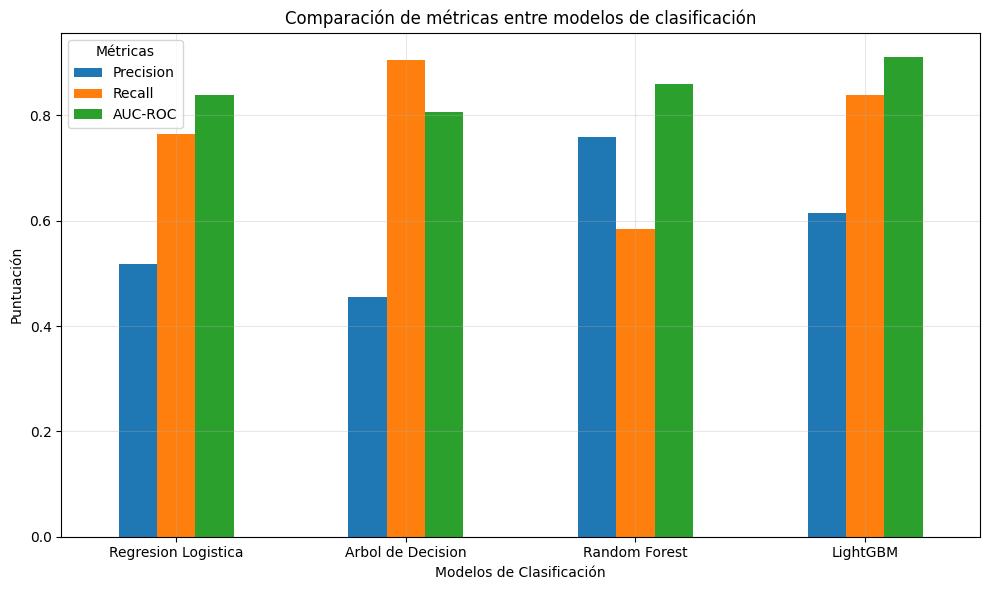

In [114]:
# Gráfico de barras para comparar métricas
df_scores.plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de métricas entre modelos de clasificación')
plt.xlabel('Modelos de Clasificación')
plt.ylabel('Puntuación')
plt.xticks(rotation=0)
plt.legend(title='Métricas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  Recomendación Estratégica:
Para Interconnect, recomiendo implementar LightGBM porque:

Detecta 8 de cada 10 clientes que se van (83.9% recall)
6 de cada 10 predicciones son correctas (61.4% precision)
Capacidad discriminativa excepcional (91.1% AUC-ROC)
Balance óptimo para maximizar retención minimizando recursos desperdiciados

### Impacto Esperado.
Con LightGBM, Interconnect podría:
- Reducir la pérdida de clientes en ~84% actuando proactivamente
- Optimizar recursos evitando 4 de cada 10 falsas alarmas comparado con el árbol de decisión
- Generar ROI positivo en campañas de retención

## Información Adicional.

Se brinda información segmentada por antigüedad en el servicio y tipos de servicio que recibe el cliente (telefonía, internet, ambos o ninguno).

In [115]:
# Creamos segmentación por tipo de servicio
def classify_service_type(row):
    has_internet = row['internet_service'] != 0  # 0 = no_contract
    has_phone = row['multiple_lines'] != 0       # 0 = no_contract

    if has_internet and has_phone:
        return 'both_services'
    elif has_internet and not has_phone:
        return 'internet_only'
    elif not has_internet and has_phone:
        return 'phone_only'
    else:
        return 'no_services'

# Aplicamos la función
df['service_type'] = df.apply(classify_service_type, axis=1)

# Vemos la distribución
print("Distribución por tipo de servicio:")
print(df['service_type'].value_counts())

Distribución por tipo de servicio:
service_type
internet_only    2885
both_services    2627
no_services      1180
phone_only        340
Name: count, dtype: int64


In [116]:
# Creamos segmentación por antigüedad
def classify_customer_age(months):
    if months <= 6:
        return 'new_customer'      # 0-6 meses
    elif months <= 24:
        return 'established'       # 6-24 meses
    else:
        return 'loyal_customer'    # +24 meses

# Aplicamos la función
df['customer_segment'] = df['months_of_age'].apply(classify_customer_age)

# Vemos la distribución
print("Distribución por antigüedad:")
print(df['customer_segment'].value_counts())

Distribución por antigüedad:
customer_segment
loyal_customer    3885
established       1983
new_customer      1164
Name: count, dtype: int64


In [117]:
# Análisis por tipo de servicio
service_analysis = df.groupby('service_type')['churned'].agg(['count', 'sum', 'mean']).round(3)
service_analysis.columns = ['total_customers', 'churned_customers', 'churn_rate']
print("Análisis por tipo de servicio:")
print(service_analysis)

Análisis por tipo de servicio:
               total_customers  churned_customers  churn_rate
service_type                                                 
both_services             2627                840       0.320
internet_only             2885                916       0.318
no_services               1180                103       0.087
phone_only                 340                 10       0.029


In [118]:
# Análisis por antigüedad
age_analysis = df.groupby('customer_segment')['churned'].agg(['count', 'sum', 'mean']).round(3)
age_analysis.columns = ['total_customers', 'churned_customers', 'churn_rate']
print("\nAnálisis por antigüedad:")
print(age_analysis)


Análisis por antigüedad:
                  total_customers  churned_customers  churn_rate
customer_segment                                                
established                  1983                731       0.369
loyal_customer               3885                590       0.152
new_customer                 1164                548       0.471


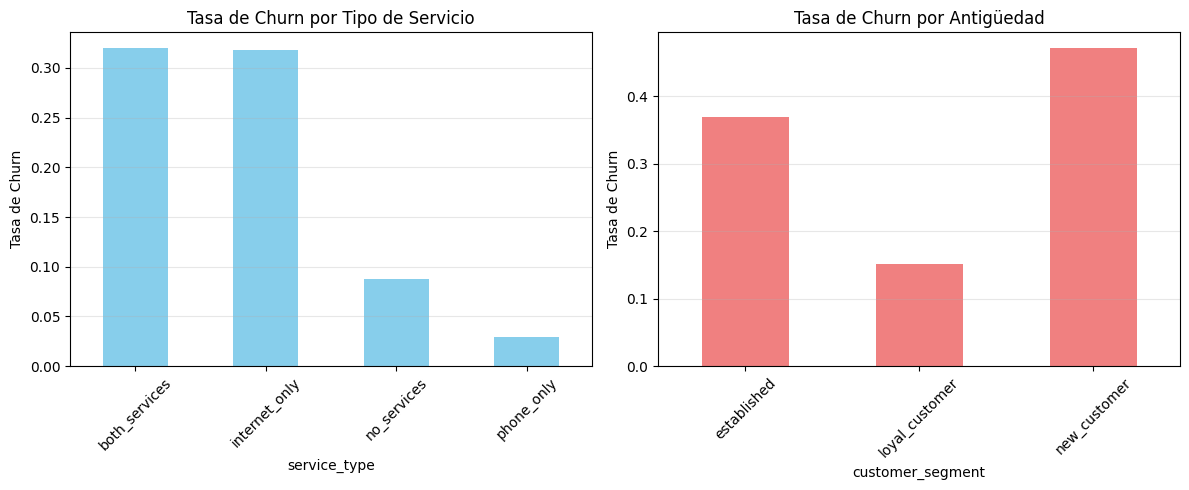

In [119]:
# Gráfico de churn por tipo de servicio
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
service_churn = df.groupby('service_type')['churned'].mean()
service_churn.plot(kind='bar', color='skyblue')
plt.title('Tasa de Churn por Tipo de Servicio')
plt.ylabel('Tasa de Churn')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
age_churn = df.groupby('customer_segment')['churned'].mean()
age_churn.plot(kind='bar', color='lightcoral')
plt.title('Tasa de Churn por Antigüedad')
plt.ylabel('Tasa de Churn')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Análisis cruzado - Tipo de servicio vs Antigüedad:
                                total_customers  churn_rate
service_type  customer_segment                             
both_services established                   587       0.552
              loyal_customer               1862       0.214
              new_customer                  178       0.657
internet_only established                   954       0.390
              loyal_customer               1249       0.143
              new_customer                  682       0.535
no_services   established                   381       0.081
              loyal_customer                512       0.014
              new_customer                  287       0.226
phone_only    established                    61       0.066
              loyal_customer                262       0.019
              new_customer                   17       0.059


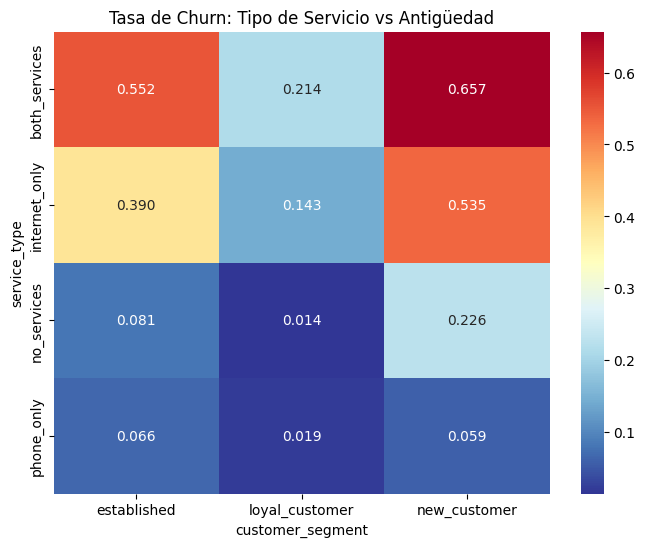

In [120]:
# Análisis cruzado: tipo de servicio + antigüedad
cross_analysis = df.groupby(['service_type', 'customer_segment'])['churned'].agg(['count', 'mean']).round(3)
cross_analysis.columns = ['total_customers', 'churn_rate']
print("Análisis cruzado - Tipo de servicio vs Antigüedad:")
print(cross_analysis)

# Heatmap para visualizar patrones
pivot_table = df.pivot_table(values='churned',
                            index='service_type',
                            columns='customer_segment',
                            aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlBu_r', fmt='.3f')
plt.title('Tasa de Churn: Tipo de Servicio vs Antigüedad')
plt.show()

### Hallazgos Clave por Segmento.

**🔴 Grupos de Mayor Riesgo:**
1. *Clientes nuevos con ambos servicios (65.7% churn).*
    - Son el grupo más vulnerable.
    - Posiblemente experimentan problemas de integración de servicios
2. *Clientes establecidos con ambos servicios (55.2% churn)*
    - Paradójicamente, tener más servicios aumenta el riesgo.
    - Sugiere problemas de calidad o precio en el paquete completo
3. *Clientes nuevos solo con internet (53.5% churn)*
    - Alta deserción en el período inicial. Posible competencia fuerte en servicios de internet
   
**🟡 Grupos de Riesgo Moderado:**
1. *Clientes establecidos solo con internet (39.0% churn).*
    - Mejoran con el tiempo pero siguen siendo vulnerables
2. *Clientes nuevos sin servicios (22.6% churn).*
    - Interesante: menor riesgo que otros grupos nuevos
   
**🟢 Grupos Más Estables:**

1. *Clientes leales con ambos servicios (21.4% churn)*
    - La lealtad compensa la complejidad del servicio
2. *Clientes leales solo con internet (14.3% churn).*
    - Segmento muy estable una vez establecido
3. *Clientes leales sin servicios (1.4% churn).*
    - El grupo más estable de todos

**Los resultados muestran que el churn se concentra en los clientes nuevos, especialmente en quienes contratan ambos servicios (65.7%) o solo internet (53.5%). Estos segmentos requieren estrategias urgentes de retención, pues la combinación de servicios o la alta competencia en internet eleva significativamente el riesgo de deserción.**

*Los clientes establecidos con estos mismos servicios aún presentan un churn moderadamente alto (39–55%), lo que sugiere problemas de percepción de valor, soporte o precio en los paquetes más complejos.*

En contraste, los clientes leales exhiben tasas de churn muy bajas (1–21%), confirmando que la antigüedad es el principal factor protector frente a la pérdida. Fomentar la fidelización temprana y mejorar la experiencia inicial del cliente deberían ser las prioridades estratégicas para reducir el churn general.
      

# Informe de Solución

1. **Pasos realizados:**

- Exploración y limpieza de datos: Análisis completo de los 4 datasets (`contract, personal, internet, phone`).
- Integración de datos: Unificación exitosa mediante `customer_id` con manejo de valores faltantes.
- Ingeniería de características: Creación de variables derivadas (antigüedad, segmentación por servicios).
- Codificación de variables: Transformación de variables categóricas a numéricas.
- División de datos: Split 75/25 para entrenamiento y validación.
- Entrenamiento de múltiples modelos: 4 algoritmos diferentes probados.
- Evaluación comparativa: Análisis detallado de métricas (Precision, Recall, AUC-ROC).
- Análisis segmentado: Insights por tipo de servicio y antigüedad del cliente.

2. **Dificultades resueltas.**
   
- Valores faltantes en los dataset. Se eliminaron 11 filas de clientes que no habían cumplido el primer mes de facturación.
- Columnas con tipos de datos incorrectos. Se ajustaron los tipos de datos para reflejar con precisión la información.
- Integración de múltiples fuentes de datos. Se creó un DataFrame con la información consolidada de los usuarios.
- Desbalance de clases en la variable objetivo. Se aplicó class_weight='balanced' para abordar este problema.
- Selección del modelo óptimo. Se entrenaron y evaluaron cuatro modelos clasificatorios, recomendando LightGBM por su desempeño superior según las métricas.

3. **Pasos clave para resolver el proyecto.**

- La creación de la variable `churned` a partir de `end_date`.
- La estrategia de manejo de valores faltantes con `'no_contract'`.
- El uso de `class_weight='balanced'` para el desbalance de clases.
- La segmentación de clientes que reveló patrones críticos.

4. **Calidad del Modelo Final.**
- Modelo recomendado: LightGBM.

    ***Métricas de rendimiento.***
    - Precision: 61.4% - 6 de cada 10 predicciones son correctas.
    - Recall: 83.9% - Detecta 8 de cada 10 clientes que se van.
    - AUC-ROC: 91.1% - Excelente capacidad discriminativa.
    - F1-Score: 70.9% - Mejor equilibrio general